# Hotel Booking: cómo afectan las cancelaciones a los hoteles

Las cancelaciones de reservas representan un desafío para la industria hotelera, ya que generan pérdidas en los ingresos, provocan una mala planificación en la ocupación y derivan en sobrecostes operativos. Estas cancelaciones pueden estar relacionadas con factores como políticas de cancelación flexibles, el uso de múltiples plataformas de reserva o la ausencia de penalizaciones por cancelar en el último minuto, entre otras.

El dataset analizado recoge reservas realizadas entre el año 2015 y 2017, de las que aproximadamente un 37% son reservas canceladas, lo que indica la importancia de este fenómeno durante este periodo. El objetivo de este estudio es desarrollar un modelo de clasificación binaria capaz de predecir con antelación la probabildiad de cancelación de una reserva, permitiendo a los hoteles elaborar estrategias de actuación que reduzcan el impacto económico y operativo de las cancelaciones, apoyándose en datos históricos.

Este problema se puede abordar con Machine Learning porque disponemos de un historial de reservas con múltiples variables predictoras (tipo de hotel, tiempo de anticipación, número de adultos, plataforma de reserva, etc.) y un target binario (cancelada/no cancelada). Existen patrones en los datos que los algoritmos de clasificación supervisada pueden aprender para predecir futuras cancelaciones.

Se propone un enfoque de clasificación supervisada, porque el objetivo es predecir una variable binaria conocida a partir de características históricas. Este enfoque permite estimar probabilidades de cancelación para nuevas reservas y, por tanto, guiar decisiones operativas. Algoritmos como Random Forest, XGBoost o regresión logística son adecuados dado que manejan variables categóricas y numéricas, toleran relaciones no lineales y permiten interpretar la importancia de las variables.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split

np.random.seed(42)


#### Carga de datos, primer vistazo y descripción:

In [2]:
df = pd.read_csv("../data_sample/hotel_booking.csv", sep= ",")
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Transient,107.0,0,0,Check-Out,2015-07-03,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,Transient,103.0,0,1,Check-Out,2015-07-03,William Velez,Velez_William@mail.com,286-669-4333,************8729
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,Transient,82.0,0,1,Canceled,2015-05-06,Steven Murphy,Steven.Murphy54@aol.com,341-726-5787,************3639
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,Transient,105.5,0,0,Canceled,2015-04-22,Michael Moore,MichaelMoore81@outlook.com,316-648-6176,************9190


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


#### Columnas irrelevantes para nuestro modelo:
En este caso, las columnas como **"name"**, **"email"**, **"phone-number"**, **"credit_card"** no son de utilidad para nuestro modelo. Las eliminaremos de nuestro dataset.

#### Data leakage:
Por otro lado, hay algunas variables cuya información es obtenida después de haber realizado una reserva, y nuestro modelo va a predecir la cancelación antes de que ocurra. Al ser data leakage, las podemos descartar:
- **reservation_status** tiene información acerca de si hicieron check-out, cancelaron o no se presentaron. Esta variable describe el resultado final de la reserva.
- **reservation_status_date** indica la fecha en la que el resultado final de la reserva se registró, contiene información futura para nuestro modelo. 

In [6]:
df.reservation_status.value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [7]:
df.reservation_status_date.value_counts()

reservation_status_date
2015-10-21    1461
2015-07-06     805
2016-11-25     790
2015-01-01     763
2016-01-18     625
              ... 
2015-04-21       1
2015-03-13       1
2015-03-29       1
2015-04-27       1
2015-03-10       1
Name: count, Length: 926, dtype: int64

#### Nulos: 
Tenemos 4 variables con nulos: children, country, agent y company, que trataremos más adelante.  
- **children:** Al ser pocos nulos, los rellenaremos con la media.
- **country:** Son pocos respecto al total del dataset y son información útil para el modelo, por lo que usaremos la moda para rellenarlos.
- **agent:** es un ID del agente de viaje que realizó la reserva. Hay muchos nulos, y no aportan información relevante al modelo, podemos prescindir de ella.
- **company:** es un ID de la empresa que realizó la reserva. Con la cantidad de nulos que tiene, no es útil para nuestro modelo.

In [5]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
df.agent.value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
444.0        1
408.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 333, dtype: int64

In [11]:
df.company.value_counts()

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
        ... 
479.0      1
489.0      1
229.0      1
481.0      1
497.0      1
Name: count, Length: 352, dtype: int64

#### Duplicados:
En este dataset, no tenemos filas duplicadas.

In [13]:
df.duplicated().sum()

np.int64(0)

#### Columnas elegidas:

In [12]:
df_hotel = df.copy()

columns_to_drop = ["name", "email", "phone-number", "credit_card", "reservation_status", "reservation_status_date", "agent", "company"]
df_hotel = df_hotel.drop(columns=columns_to_drop)

df_hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## Análisis inicial del dataset 
El dataset tiene un total de 119.390 filas y 36 columnas inicialmente. Tras eliminar las columnas que no usaremos en nuestro modelo, continuaremos con 28 columnas. De estas, 10 son tipo string, 16 de tipo int y 2 de tipo float. 

### Clasificación inicial de variables: 

- **Variables numéricas continuas:** 
    - lead_time
    - adr 

- **Variables numéricas discretas:** 
    - adults
    - children
    - babies
    - required_car_parking_spaces
    - total_of_special_requests
    - days_in_waiting_list
    - previous_cancellations
    - previous_bookings_not_canceled
    - booking_changes
    - stays_in_week_nights
    - stays_in_weekend_nights
    - arrival_date_year
    - arrival_date_day_of_month
    - arrival_date_week_number

- **Variables categóricas:**
    - hotel
    - customer_type
    - market_segment
    - deposit_type
    - meal
    - country
    - distribution_channel
    - reserved_room_type
    - assigned_room_type
    - arrival_date_month

- **Variables binarias:** 
    - is_repeated_guest

- **Variable objetivo:** 
    - is_canceled

La tipificación inicial se realizó inspeccionando las variables y sus valores únicos, asegurando que la separación entre continuas, discretas, categóricas, binarias y temporales sea coherente con la naturaleza de los datos.



### Análisis del target - is_cancelled:

En nuestra variable target interpretamos que el valor que es 0 se refiere a "no" y 1 significa "sí". No hay un desbalance grande, y nos sirve para confirmar que las cancelaciones son un problema relevante. En nuestro set de train, un 62% de las reservas no son canceladas, frente al 37% que sí cancelan. 

In [15]:
df_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [14]:
target = "is_canceled"

### Train/Test split:


In [16]:
# tenemos nuestro df_hotel limpio y sin columnas irrelevantes:
X = df_hotel.drop(columns="is_canceled")
y = df_hotel["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

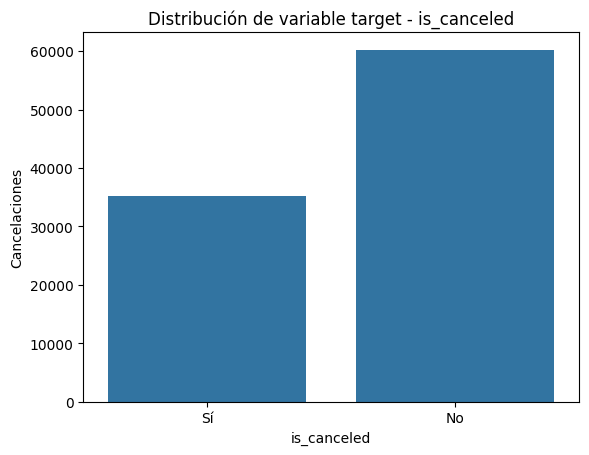

In [17]:
# vemos la distribución del target, donde 0 es "No" y 1 es "Sí" y usamos map para cambiar
# estos valores y visualizar:
y_train_etiquetas = y_train.map({0: "No", 1: "Sí"})

sns.countplot(x=y_train_etiquetas)
plt.title("Distribución de variable target - is_canceled")
plt.ylabel("Cancelaciones")
plt.show();

In [18]:
# Vemos el porcentaje de cancelaciones en nuestro train, muy similar al df original:
print(y_train.value_counts(normalize=True) * 100)


is_canceled
0    63.090502
1    36.909498
Name: proportion, dtype: float64


## Análisis de variables numéricas:


### Numéricas continuas:

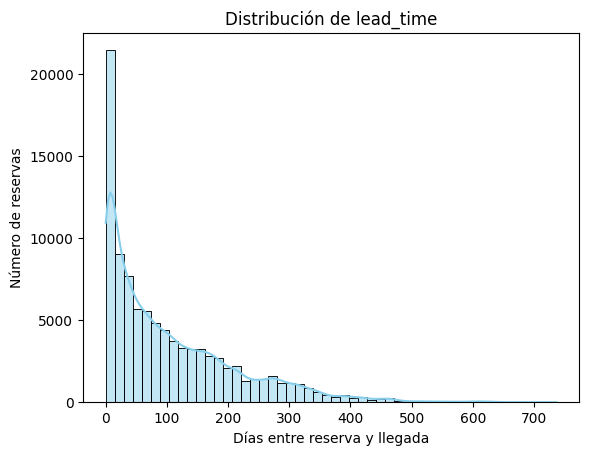

In [78]:
# lead_time:
sns.histplot(train_set["lead_time"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de lead_time")
plt.xlabel("Días entre reserva y llegada")
plt.ylabel("Número de reservas")
plt.show();

/var/folders/r5/mbjy65314c11vp7t3hw_9m7m0000gn/T/ipykernel_4554/1428295500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_canceled", y="lead_time", data=train_set, palette=["lightgreen","salmon"])


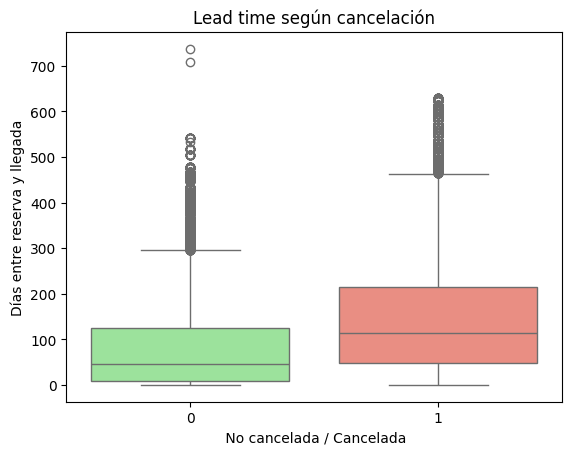

In [81]:
# Lead time vs cancelación:
sns.boxplot(x="is_canceled", y="lead_time", data=train_set, palette=["lightgreen","salmon"])
plt.title("Lead time según cancelación")
plt.xlabel(" No cancelada / Cancelada")
plt.ylabel("Días entre reserva y llegada")
plt.show();

- Las reservas que se cancelan tienen un mayor espacio en días entre reserva y llegada.
- Las reservas que se mantienen se hacen con menor antelación.
- La mediana en las reservas canceladas es más alta que la mediana de las que se mantienen; esto quiere decir que cuanto más días hay entre reserva y llegada, mayor es la probabilidad de que se cancele.

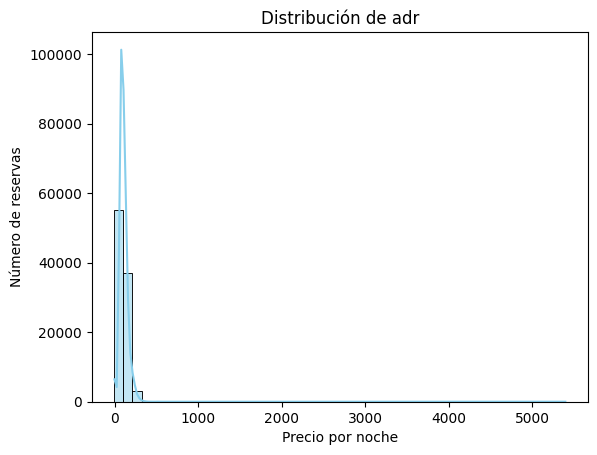

In [ ]:
# adr (average daily rate):
sns.histplot(train_set["adr"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de adr")
plt.xlabel("Precio por noche")
plt.ylabel("Número de reservas")
plt.show();

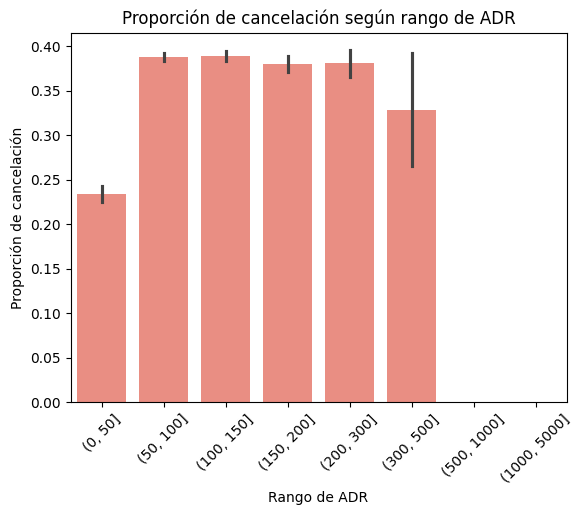

In [86]:
# adr vs cancelación:

# Crear bins de ADR
bins = [0, 50, 100, 150, 200, 300, 500, 1000, 5000]
train_set["adr_range"] = pd.cut(train_set["adr"], bins)

sns.barplot(x="adr_range", y="is_canceled", data=train_set, color="salmon")
plt.xticks(rotation=45)
plt.ylabel("Proporción de cancelación")
plt.xlabel("Rango de ADR")
plt.title("Proporción de cancelación según rango de ADR")
plt.show()

- Las reservas con costo inferior a 50€ tienen una proporción de cancelación menor respecto a las reservas entre 50 y 300 aproximadamente. Además, la confianza en la proporción es buena, exceptuando para los rangos a partir de 300€ donde la confianza en la proporción baja y hay mucha variabilidad en los datos. 
- Al tener una escala muy grande (de 0-5000), para poder utilizarla en nuestro modelo y ya que aporta información importante, deberemos transformar la variable (con un log-transform para reducir el efecto de los valores grandes).

### Numéricas discretas:

In [34]:
# vemos los valores de las variables discretas para entender su distribución:
vars_discretas = ["adults","children","babies","required_car_parking_spaces",
             "total_of_special_requests","days_in_waiting_list",
             "previous_cancellations","previous_bookings_not_canceled",
             "booking_changes","stays_in_week_nights","stays_in_weekend_nights",
             "arrival_date_year","arrival_date_day_of_month","arrival_date_week_number"]

for col in vars_discretas:
    print(f"Para la columna '{col}' hay:")
    print(df_hotel[col].value_counts())
    print("\n")

Para la columna 'adults' hay:
adults
2     89680
1     23027
3      6202
0       403
4        62
26        5
27        2
20        2
5         2
40        1
50        1
55        1
6         1
10        1
Name: count, dtype: int64


Para la columna 'children' hay:
children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64


Para la columna 'babies' hay:
babies
0     118473
1        900
2         15
10         1
9          1
Name: count, dtype: int64


Para la columna 'required_car_parking_spaces' hay:
required_car_parking_spaces
0    111974
1      7383
2        28
3         3
8         2
Name: count, dtype: int64


Para la columna 'total_of_special_requests' hay:
total_of_special_requests
0    70318
1    33226
2    12969
3     2497
4      340
5       40
Name: count, dtype: int64


Para la columna 'days_in_waiting_list' hay:
days_in_waiting_list
0      115692
39        227
58        164
44        141
31        127
        ...  
81      

In [ ]:
# para visualizar mis variables, voy a usar un set solo del train donde estén juntas las variables y el target:
train_set = X_train.copy()
train_set[target] = y_train
train_set.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
67702,City Hotel,64,2017,May,18,6,2,1,3,0.0,...,D,D,0,No Deposit,0,Transient,189.00,0,0,1
115851,City Hotel,34,2017,July,28,10,1,1,2,1.0,...,A,A,0,No Deposit,0,Transient,146.00,0,0,0
57345,City Hotel,8,2016,September,39,24,1,1,2,2.0,...,F,F,0,No Deposit,0,Transient,259.00,0,0,1
11622,Resort Hotel,251,2017,May,21,21,2,4,2,0.0,...,E,E,0,No Deposit,0,Transient,89.70,0,1,1
33333,Resort Hotel,23,2017,February,7,18,1,1,2,0.0,...,D,D,0,No Deposit,0,Transient,42.43,0,1,0


#### - Variables con pocos valores únicos:

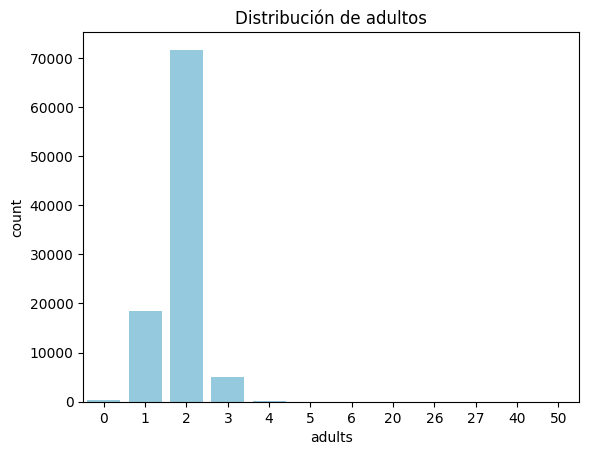

In [61]:
sns.countplot(x="adults", data=train_set, color="skyblue")
plt.title("Distribución de adultos")
plt.show();

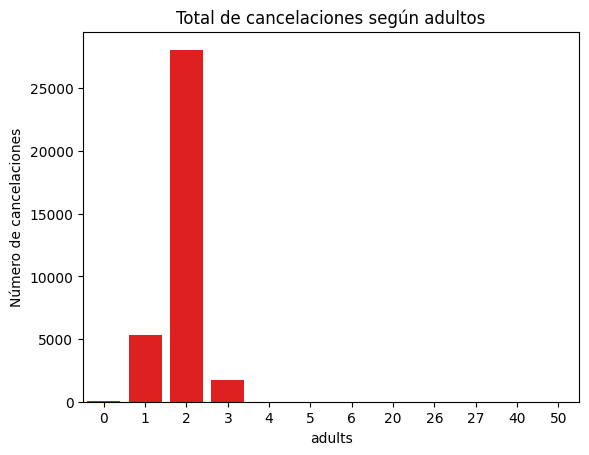

In [62]:
# relación con el target:
sns.countplot(x="adults", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según adultos")
plt.ylabel("Número de cancelaciones")
plt.show();

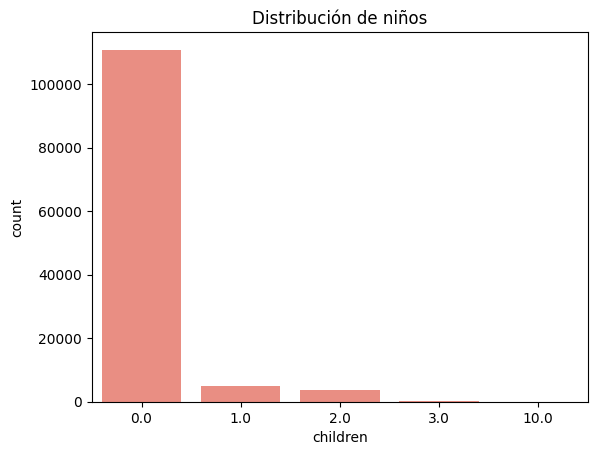

In [ ]:
sns.countplot(x="children", data=train_set, color="salmon")
plt.title("Distribución de niños")
plt.show();

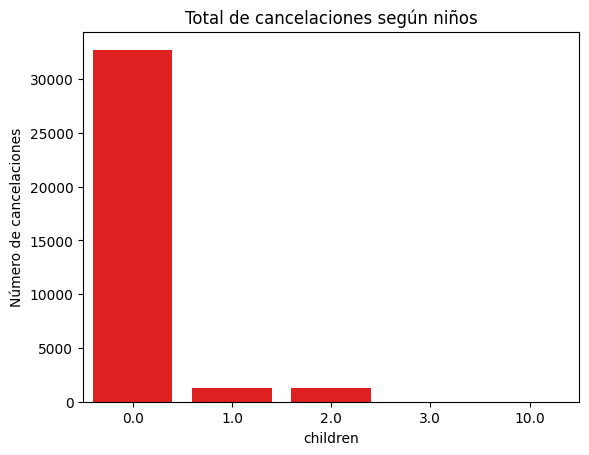

In [63]:
sns.countplot(x="children", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según niños")
plt.ylabel("Número de cancelaciones")
plt.show();

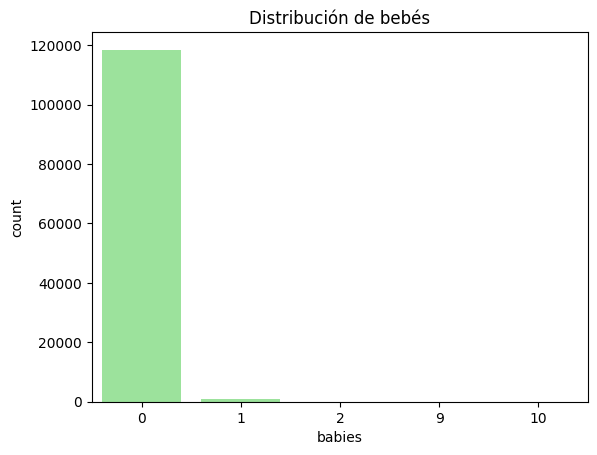

In [ ]:
sns.countplot(x="babies", data=train_set, color="lightgreen")
plt.title("Distribución de bebés")
plt.show();

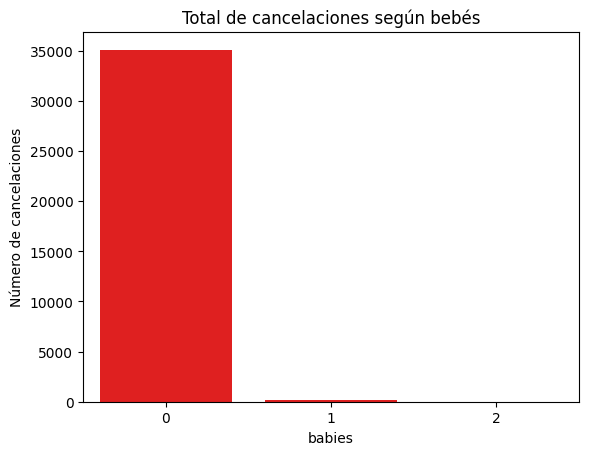

In [64]:
sns.countplot(x="babies", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según bebés")
plt.ylabel("Número de cancelaciones")
plt.show();

#### - Variables con rango medio:

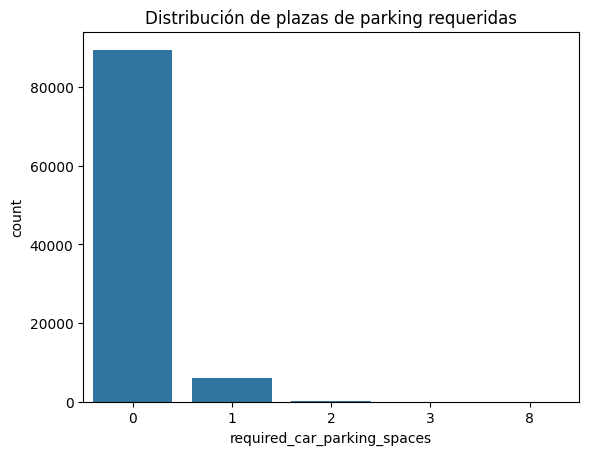

In [65]:
sns.countplot(x="required_car_parking_spaces", data=train_set)
plt.title("Distribución de plazas de parking requeridas")
plt.show();

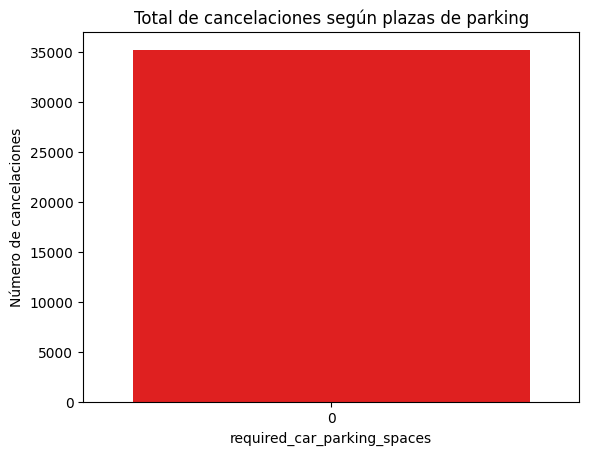

In [67]:
# relación con target:
sns.countplot(x="required_car_parking_spaces", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según plazas de parking")
plt.ylabel("Número de cancelaciones")
plt.show();

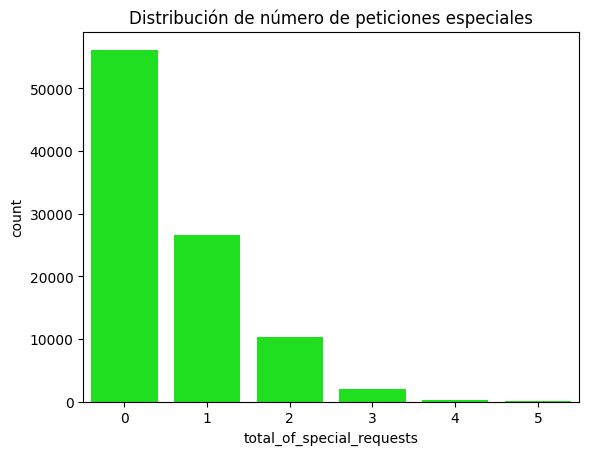

In [75]:
# total_of_special_requests:
sns.countplot(x="total_of_special_requests", data=train_set, color="lime")
plt.title("Distribución de número de peticiones especiales")
plt.show();

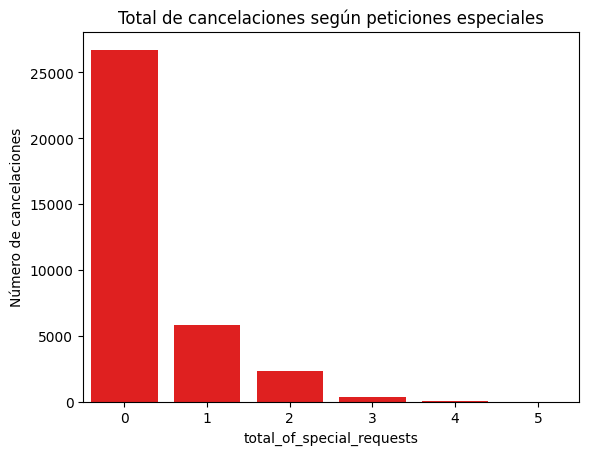

In [70]:
# relación con target:
sns.countplot(x="total_of_special_requests", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Total de cancelaciones según peticiones especiales")
plt.ylabel("Número de cancelaciones")
plt.show();

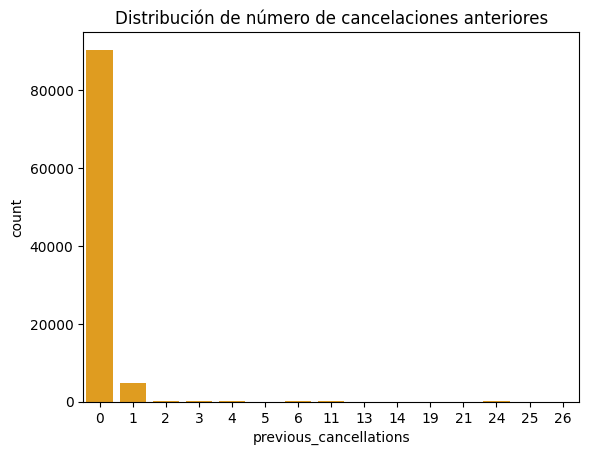

In [76]:
# previous_cancelations:
sns.countplot(x="previous_cancellations", data=train_set, color="orange")
plt.title("Distribución de número de cancelaciones anteriores")
plt.show();

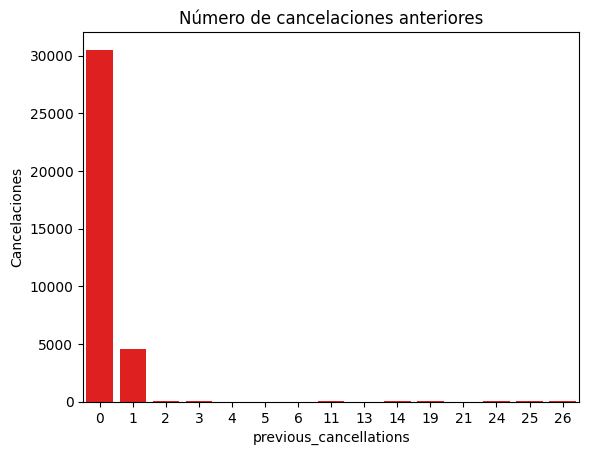

In [72]:
# relación con target:
sns.countplot(x="previous_cancellations", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Número de cancelaciones anteriores")
plt.ylabel("Cancelaciones")
plt.show();

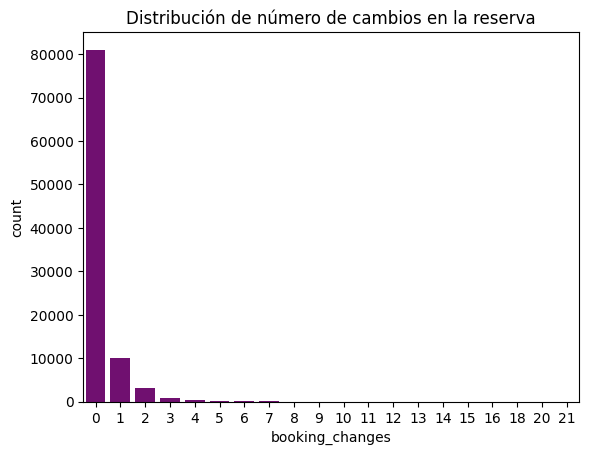

In [77]:
# booking_changes:
sns.countplot(x="booking_changes", data=train_set, color="purple")
plt.title("Distribución de número de cambios en la reserva")
plt.show();

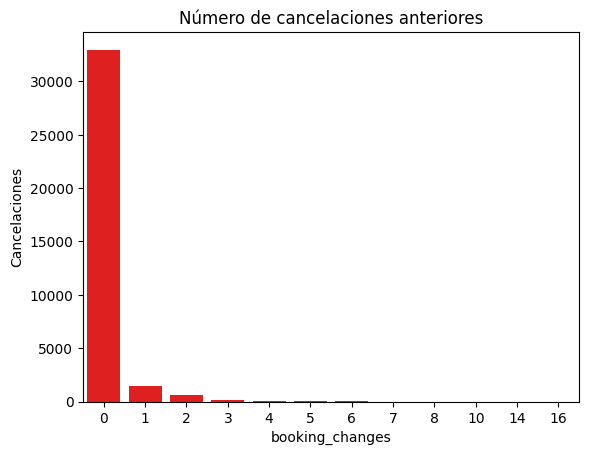

In [74]:
sns.countplot(x="booking_changes", data=train_set[train_set["is_canceled"]==1], color="red")
plt.title("Número de cancelaciones anteriores")
plt.ylabel("Cancelaciones")
plt.show();

### - Variables con rango amplio:

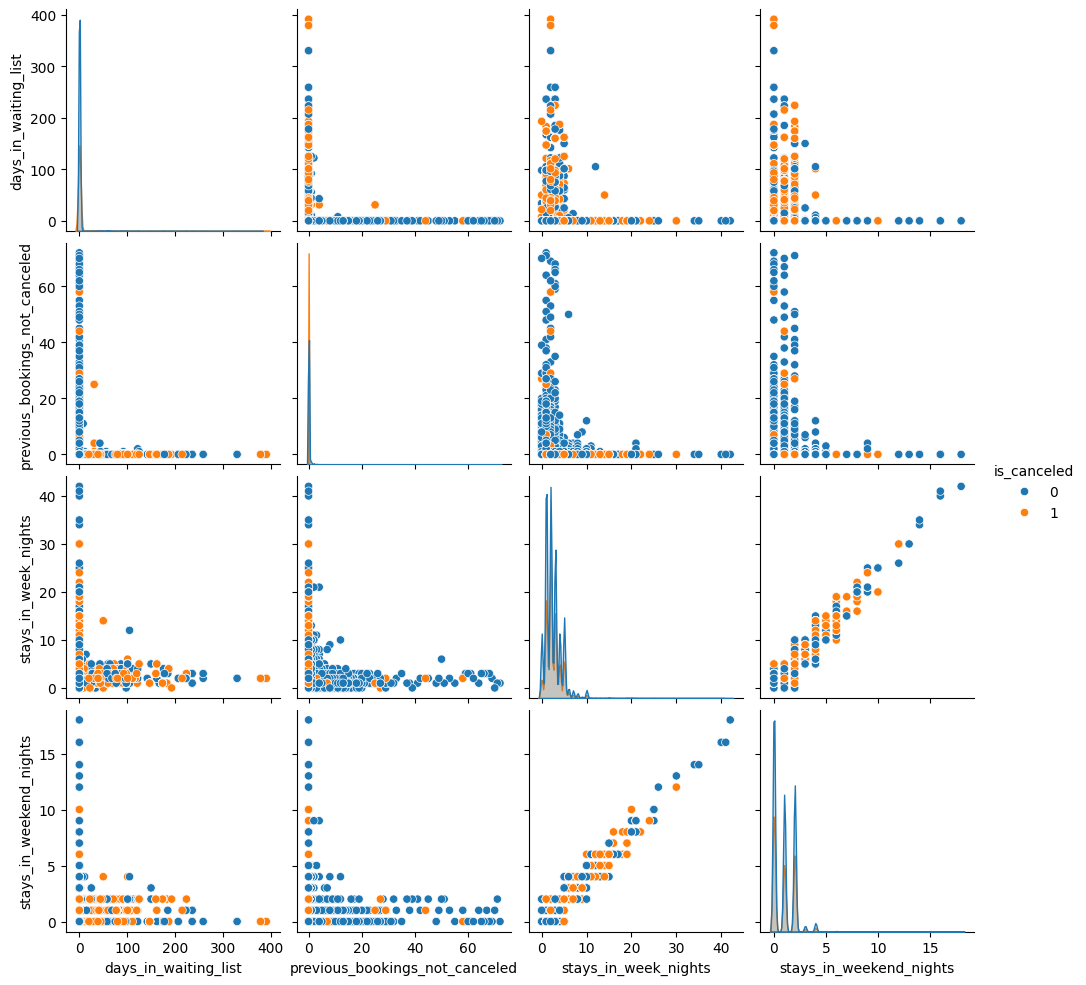

In [ ]:
# numéricas discretas con rango amplio:
num_disc_rango = ["days_in_waiting_list", "previous_bookings_not_canceled", "stays_in_week_nights", "stays_in_weekend_nights"]
sns.pairplot(train_set[num_disc_rango + [target]], hue= target)
plt.show();

### Análisis temporal para detectar estacionalidad:
Nuestro target puede verse afectado por las variables temporales que tenemos. Veamos la relación que tienen: 

In [ ]:
# distribución de cancelaciones por año:
X_train.arrival_date_year.value_counts()

arrival_date_year
2016    45355
2017    32550
2015    17607
Name: count, dtype: int64

In [ ]:
# Agrupamos por años y meses y calculamos la media de las cancelaciones, para establecer temporalidad:
df_train = X_train.copy()
df_train["is_canceled"] = y_train

cancel_by_month = (df_train.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean() * 100).sort_index()
print(cancel_by_month)

arrival_date_year  arrival_date_month
2015               August                41.241469
                   December              32.715517
                   July                  45.235935
                   November              20.378151
                   October               34.606685
                   September             40.650012
2016               April                 37.764004
                   August                35.448954
                   December              36.286645
                   February              34.440503
                   January               24.916201
                   July                  32.984004
                   June                  39.084006
                   March                 30.482115
                   May                   35.187698
                   November              36.968160
                   October               40.540541
                   September             37.294036
2017               April                 43.

- Inicialmente, hay aproximadamente 3 veces más cancelaciones en el 2016 que en el 2015.
- Sin embargo, al revisar la media de las cancelaciones por meses y años, vemos que no tenemos información de todos los meses de los años:
    - del 2015, tenemos información de 6 meses, de julio a diciembre.
    - del 2016, tenemos información de todos los meses del año.
    - del 2017 tenemos información de 8 meses, de enero a agosto solamente. 
- A partir de esto, vemos que en el 2015 el mayor mes de cancelación fue en julio; en el 2016, fue en octubre; en 2017 fue mayor y similar en abril, mayo y junio.

#### Veámoslo gráficamente con un heatmap:

In [29]:
# ordenamos los meses para que se visualicen en orden temporal y no alfabético:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
# pd.Categorical lo usamos para convertir la col arrival_date_month en un tipo categórico ordenado, en vez de str ya que los ordena alfabéticamente.
df_hotel["arrival_date_month"] = pd.Categorical(
    df_hotel["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [27]:
# Creamos la tabla pivote para visualizar la media de cancelaciones por año y mes, con los meses ordenados:
pivot = (df_hotel.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean().unstack() * 100)
# unstack convierte la segunda col arrival_date_month en columnas y deja los años como filas, y 
# resulta una matriz tipo tabla con años vs meses

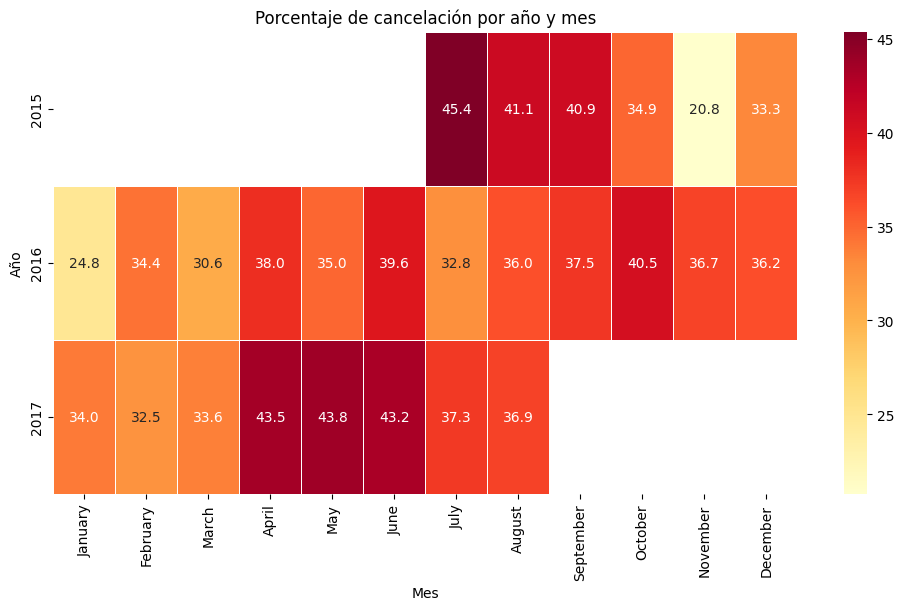

In [28]:
# Dibujamos el heatmap:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot, # usa la tabla pivote
    annot=True, # muestra los valores numéricos dentro de cada celda
    fmt=".1f", # con un decimal
    cmap="YlOrRd", # escala de colores amarillo a rojo
    linewidths=0.5 # separación entre celdas
)

plt.title("Porcentaje de cancelación por año y mes")
plt.ylabel("Año")
plt.xlabel("Mes")
plt.show();

### Resultados visuales:
- En el 2015, hubo más cancelaciones en julio, agosto y septiembre, temporada de verano.
- En el 2016, la tasa de cancelaciones se concentró en abril, junio y octubre, siendo octubre el mes con más cancelaciones, no hay una temporada clara.
- En el 2017, se concentraron las cancelaciones entre abril, mayo y junio, estando bastante igualadas en porcentaje, en la temporada de primavera.

## Análisis de variables categóricas:

In [ ]:
vars_categoricas = ["adults","children","babies","required_car_parking_spaces",
             "total_of_special_requests","days_in_waiting_list",
             "previous_cancellations","previous_bookings_not_canceled",
             "booking_changes","stays_in_week_nights","stays_in_weekend_nights",
             "arrival_date_year","arrival_date_day_of_month","arrival_date_week_number"]

for col in vars_discretas:
    print(f"Para la columna '{col}' hay:")
    print(df_hotel[col].value_counts())
    print("\n")

### Segmentación de clientes:


### Conclusión del EDA: 

In [ ]:
# luego usar para ver relación con target numéricas:
# get_features_num_regression y el plot